# PCA & t-SNE — Dimensionality Reduction

**Goal:** Understand two fundamental dimensionality-reduction techniques, when to use each, and how to visualize high-dimensional data.

**Why it matters:**
- **PCA** — the workhorse of linear dimensionality reduction. Used for compression, denoising, and speed.
- **t-SNE** — the standard for visualization. Turns 784-dim MNIST into a 2D picture where digits separate.

**Prerequisite:** [02-scaling-encoding.ipynb](./02-scaling-encoding.ipynb)

**Datasets:** Titanic (for PCA demo) + Digits (for t-SNE demo — visual separation is dramatic).

---

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

print("Setup complete.")

Setup complete.


##  The Curse of Dimensionality

As dimensions grow, data becomes sparse, distances lose meaning, and models need exponentially more data.

**Symptoms:**
- Model overfits easily
- Slow training
- Distances between points converge (everything looks "far")
- Visualization impossible beyond 3D

**Two ways to fight it:**
- **Feature selection** — pick the most useful features (we'll do this later)
- **Feature extraction** — combine features into fewer, richer ones (**PCA, t-SNE**)

---

##  PCA — The Intuition

**PCA (Principal Component Analysis)** finds new axes (components) that:
1. Are **linear combinations** of the original features
2. Are **orthogonal** to each other
3. **Maximize variance** captured


**Key properties:**
- Deterministic (no randomness)
- Components are ordered by explained variance
- Works on any numeric data (after scaling!)

**Important:** PCA assumes linearity. Non-linear manifolds (like a Swiss roll) need t-SNE, UMAP, or autoencoders.

In [22]:

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["HasCabin"] = df["Cabin"].notna().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Sex_encoded"] = (df["Sex"] == "male").astype(int)

# Numeric features for PCA
numeric_features = ["Age", "Fare", "SibSp", "Parch", "Pclass", "FamilySize", "HasCabin", "Sex_encoded"]
X = df[numeric_features].copy()
y = df["Survived"]

print("Shape:", X.shape)

Shape: (891, 8)


In [23]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print(pd.DataFrame(X_scaled, columns=numeric_features).describe().loc[["mean", "std"]].round(2))

      Age  Fare  SibSp  Parch  Pclass  FamilySize  HasCabin  Sex_encoded
mean  0.0   0.0    0.0    0.0    -0.0        -0.0      -0.0         -0.0
std   1.0   1.0    1.0    1.0     1.0         1.0       1.0          1.0


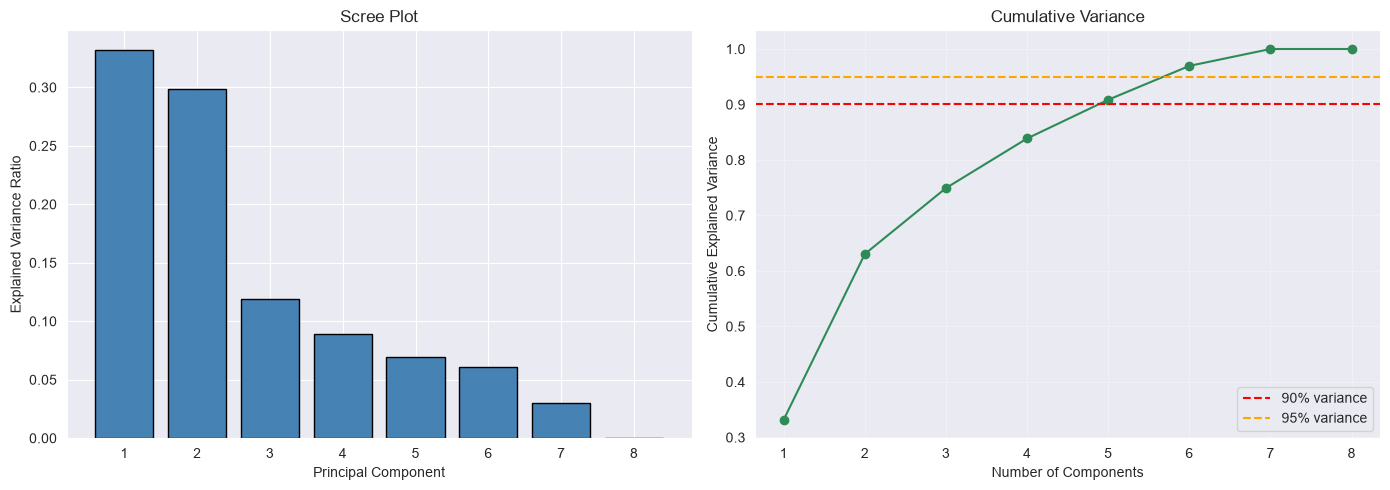

Components for 90% variance: 5
Components for 95% variance: 6


In [24]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)



explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(range(1, len(explained) + 1), explained, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(range(1, len(explained) + 1))


axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="seagreen")
axes[1].axhline(y=0.90, color="red", linestyle="--", label="90% variance")
axes[1].axhline(y=0.95, color="orange", linestyle="--", label="95% variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

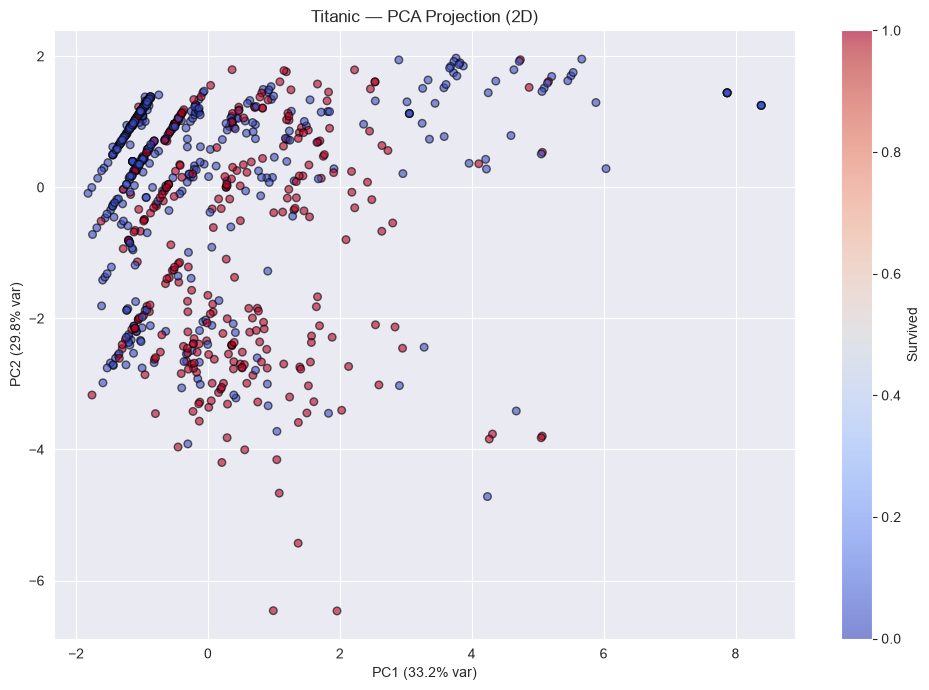

In [25]:
# Project to 2D and color by survival
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=y, cmap="coolwarm", alpha=0.6, s=30, edgecolor="k")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Titanic — PCA Projection (2D)")
plt.colorbar(scatter, label="Survived")
plt.tight_layout()
plt.show()

In [26]:
results = []


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline_scores = cross_val_score(baseline, X_scaled, y, cv=5, scoring="accuracy")
results.append(("No PCA (8 features)", baseline_scores.mean(), baseline_scores.std()))


for n in [2, 3, 4, 5, 6]:
    pca_n = PCA(n_components=n)
    X_pca_n = pca_n.fit_transform(X_scaled)
    scores = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                             X_pca_n, y, cv=5, scoring="accuracy")
    results.append((f"PCA n={n}", scores.mean(), scores.std()))



print(f"{'Configuration':<25} {'Mean Acc':<12} {'Std':<10}")
print("-" * 50)
for name, mean, std in results:
    print(f"{name:<25} {mean:.4f}       {std:.4f}")

Configuration             Mean Acc     Std       
--------------------------------------------------
No PCA (8 features)       0.7980       0.0102
PCA n=2                   0.6892       0.0384
PCA n=3                   0.7991       0.0155
PCA n=4                   0.7968       0.0086
PCA n=5                   0.8002       0.0069
PCA n=6                   0.7946       0.0107


## t-SNE — The Intuition

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is a **non-linear** dimensionality reduction method designed for **visualization**.

**How it works (intuitively):**
1. In high-D, compute pairwise similarities between points
2. In low-D (usually 2D), place points randomly
3. Move points so that low-D similarities match high-D similarities

**Key differences from PCA:**

| Aspect | PCA | t-SNE |
|--------|-----|-------|
| Type | Linear | Non-linear |
| Purpose | Compression, denoising | Visualization |
| Deterministic | Yes | No (random init) |
| Preserves | Global variance | Local neighborhoods |
| Speed | Fast | Slow (O(n²)) |
| Distances in output | Meaningful | **Not meaningful globally** |



In [28]:

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("Digits shape:", X_digits.shape)
print("Classes:", np.unique(y_digits))


X_digits_scaled = StandardScaler().fit_transform(X_digits)


tsne = TSNE(n_components=2,  random_state=42)
X_tsne = tsne.fit_transform(X_digits_scaled)

print("t-SNE done. Output shape:", X_tsne.shape)

Digits shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
t-SNE done. Output shape: (1797, 2)


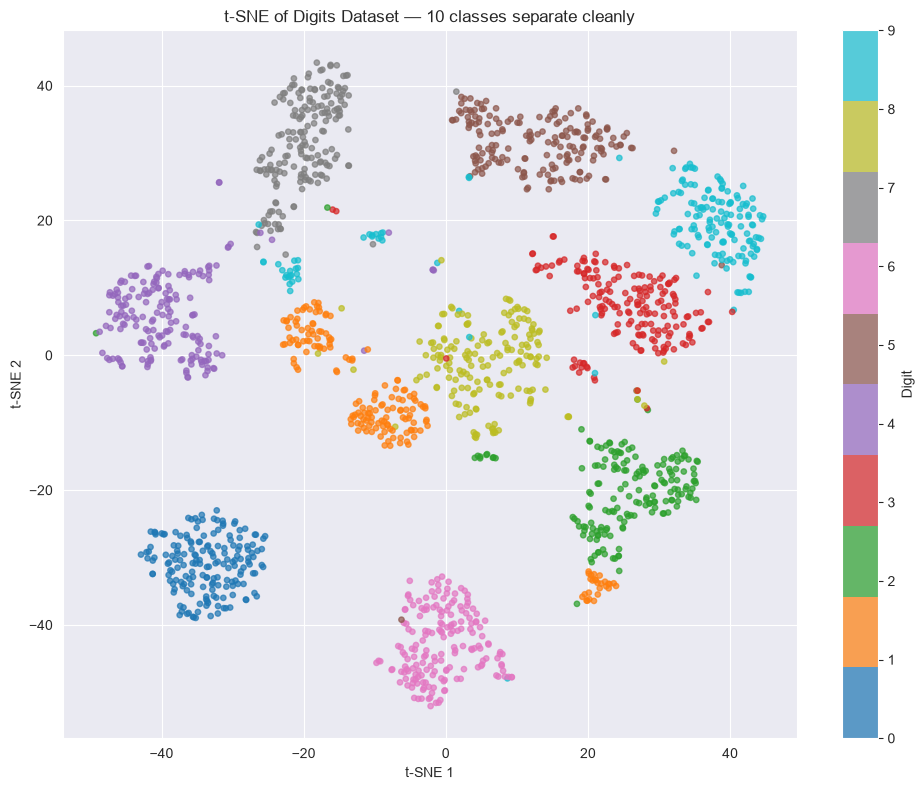

In [29]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=y_digits, cmap="tab10", alpha=0.7, s=15)
plt.colorbar(scatter, label="Digit")
plt.title("t-SNE of Digits Dataset — 10 classes separate cleanly")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

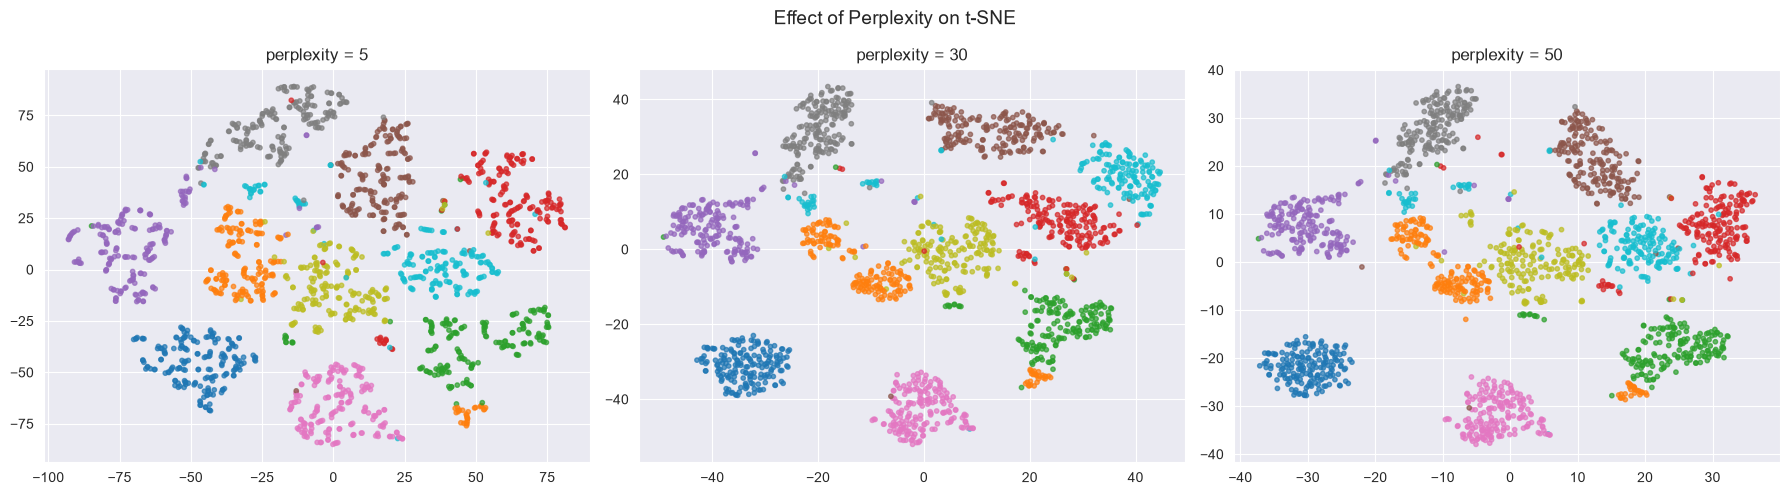

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [5, 30, 50]):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42,
                  init="pca", learning_rate="auto")
    X_p = tsne_p.fit_transform(X_digits_scaled)

    ax.scatter(X_p[:, 0], X_p[:, 1], c=y_digits, cmap="tab10", alpha=0.7, s=10)
    ax.set_title(f"perplexity = {perp}")

plt.suptitle("Effect of Perplexity on t-SNE", fontsize=14)
plt.tight_layout()
plt.show()